In [11]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import LogNorm
import pickle
from datetime import datetime
from pathlib import Path

import sys
sys.path.append('../../')
from codebase.pairwise_copy_spatial_simulations import Simulate_Fish_School_Excluded_Volume, Simulate_Fish_School
from codebase.subgroup_analysis import convert_to_focal_distance
from matplotlib.ticker import MaxNLocator

In [13]:
fish_ages = [2,4,6,8] # weeks
bodylengths = [4,7,10,12] # mm, from Zada et. al. 2024
arena_radius = [75, 150, 150, 150] # mm, radius of experimental arena for each age group

with open('../../Results/experiments_subgroup_analysis_results.pkl', 'rb') as f:
    data_focal_distances_agewise = pickle.load(f)["focal_distances"]

microscopic_params = pd.read_csv('../../Results/microscopic_params_full_dataset.csv').to_numpy()

# Quantify angular density of neighbors in data
We will calculate angular density using neighbors radial distance $R\leq 2$ bodylengths away, to capture the short-range angular anisotropy observed in spatial density plots. Optimal turn magnitude $\omega$ for simulations is the one that results in the best match to the angular density curves seen in data.

In [14]:
nbins_theta = 60
bins_theta_edges = np.linspace(-np.pi, np.pi, nbins_theta+1)
angular_density_curves_data = []

for j in range(len(fish_ages)):
    dLR = data_focal_distances_agewise[j][:,0]
    dFB = data_focal_distances_agewise[j][:,1]

    r = np.sqrt(dLR**2 + dFB**2)
    head_angles = np.arctan2(dFB, dLR)  # angle measured from x axis. heading angle of focal fish = pi/2 in these coordinates
    # bin data by angle (only considering r < 2 * BL)
    theta_red = head_angles[r < 2 * bodylengths[j]]
    angular_hist, _ = np.histogram(theta_red, bins=bins_theta_edges, density=True)
    bins_t = (bins_theta_edges[:-1] + bins_theta_edges[1:]) / 2
    angular_density_curves_data.append(np.column_stack((bins_t,angular_hist)))


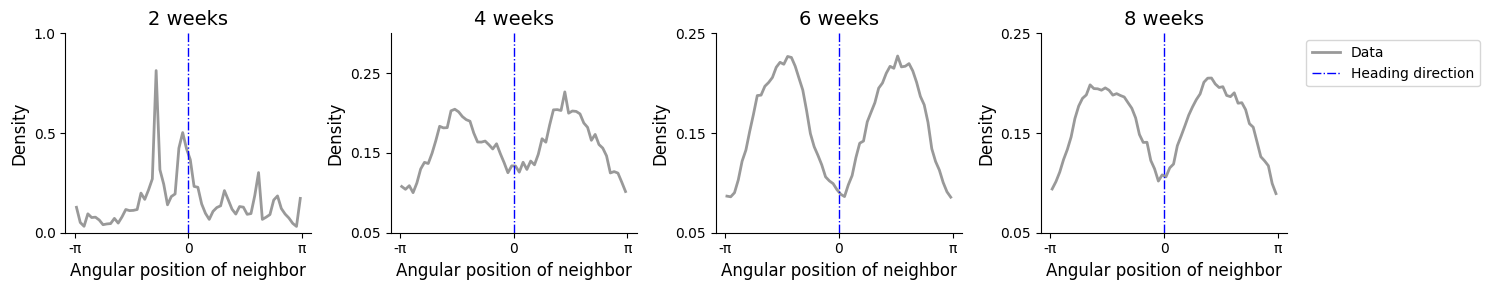

In [15]:
# angular density data 
fig, ax = plt.subplots(1, 4, figsize=(15, 3))
lims = [[0,1], [0.05,0.3], [0.05,0.25], [0.05,0.25]]
ticks = [[0,0.5,1], [0.05,0.15,0.25], [0.05,0.15,0.25], [0.05,0.15,0.25]]
for j in range(len(fish_ages)):
    angles = np.copy(angular_density_curves_data[j][:,0])
    angles[angles<-np.pi/2] += 2*np.pi
    angles = angles - np.pi/2 # shift so that 0 is heading direction

    # sort angles and corresponding densities
    sorted_indices = np.argsort(angles)
    angles = angles[sorted_indices]
    ax[j].plot(angles, angular_density_curves_data[j][sorted_indices,1], color='grey', label='Data', linewidth=2, alpha=0.8)
    ax[j].set_title(f"{fish_ages[j]} weeks", fontsize=14)
    ax[j].set_xlabel('Angular position of neighbor', fontsize=12)
    ax[j].set_ylabel('Density', fontsize=12)
    ax[j].set_xticks([-np.pi, 0, np.pi],['-π', '0',  'π'])
    ax[j].tick_params(axis='both', which='major', labelsize=10)
    ax[j].set_ylim(lims[j])
    ax[j].set_yticks(ticks[j])
    #ax[j].yaxis.set_major_locator(MaxNLocator(nbins=4))
    # turn off top and right spines
    ax[j].spines['top'].set_visible(False)
    ax[j].spines['right'].set_visible(False)
    ax[j].axvline(0, color='b', linestyle='-.', linewidth=1, label='Heading direction')
ax[-1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
fig.tight_layout()

# Perform a grid search over $\omega$ to find optimal turn magnitude
Save raw dFB and dLR values for each $\omega$

In [16]:
n_sims = 100
dt = 0.01 #s
Tmax = 600 #s
L = 50 #mm
omega_list = 10**np.linspace(-2.5,0,21)
N = 4

results_path = Path('../../Results/excluded_volume_param_scan_results.pkl')
if results_path.is_file():
    # load results 
    with open(results_path, 'rb') as f:
        results = pickle.load(f)
        MSE_angular_density = results['MSE_angular_density']
        angular_histograms = results['angular_histograms']
else:
    MSE_angular_density = np.zeros((len(omega_list), len(fish_ages)))
    angular_histograms = np.zeros((len(omega_list), len(fish_ages), nbins_theta,2))

    for i,omega in enumerate(omega_list):  

        for j in range(len(fish_ages)):
            R = arena_radius[j] #mm, radius of arena
            s = microscopic_params[j,0] * np.ones(N) # s^-1, rate of diffusion
            eps = microscopic_params[j,1]* np.ones(N) # std of diffusion noise
            c = microscopic_params[j,2]* np.ones(N) # s^-1, rate of copying 
            v = np.ones(N)*microscopic_params[j,3] #mm/s, velocity of each fish

            R_ex = bodylengths[j] # excluded volume radius
            
            dFB_all_sims = []
            dLR_all_sims = []

            for kk in range(n_sims):
                sim = Simulate_Fish_School_Excluded_Volume(N=N,v=v,R=R,s=s,eps=eps,c=c,Tmax=Tmax,dt=dt, L=L,R_ex=R_ex,omega=omega,seed=kk)
                x, y, head_angles = sim.run_simulation()
                for f in range(N):
                    dFB, dLR = convert_to_focal_distance(f,x,y,head_angles)
                    nan_mask = np.isfinite(dLR+dFB)
                    dFB_all_sims.append(dFB[nan_mask])
                    dLR_all_sims.append(dLR[nan_mask])

            dFB_all_sims = np.concatenate(dFB_all_sims)
            dLR_all_sims = np.concatenate(dLR_all_sims)

            r = np.sqrt(dLR_all_sims**2 + dFB_all_sims**2)
            theta = np.arctan2(dFB_all_sims, dLR_all_sims)  # angle measured from x axis. heading angl of focal fish = pi/2 in these coordinates

            # bin data by angle (only considering r < 2 * BL)
            theta_red = theta[r < 2 * bodylengths[j]]
            angular_hist, _ = np.histogram(theta_red, bins=bins_theta_edges, density=True)
            # compute error between simulation and data
            angular_error = np.mean((angular_hist - angular_density_curves_data[j][:,1])**2)
            MSE_angular_density[i,j] = angular_error
            angular_histograms[i,j,:,0] = (bins_theta_edges[:-1] + bins_theta_edges[1:]) / 2
            angular_histograms[i,j,:,1] = angular_hist

        print(f"Finished omega={omega:.3f} at {datetime.now()}")

    # save results 
    with open('../../Results/excluded_volume_param_scan_results.pkl', 'wb') as f:
        pickle.dump({
            'omega_list': omega_list,
            'MSE_angular_density': MSE_angular_density,
            'angular_histograms': angular_histograms
        }, f)

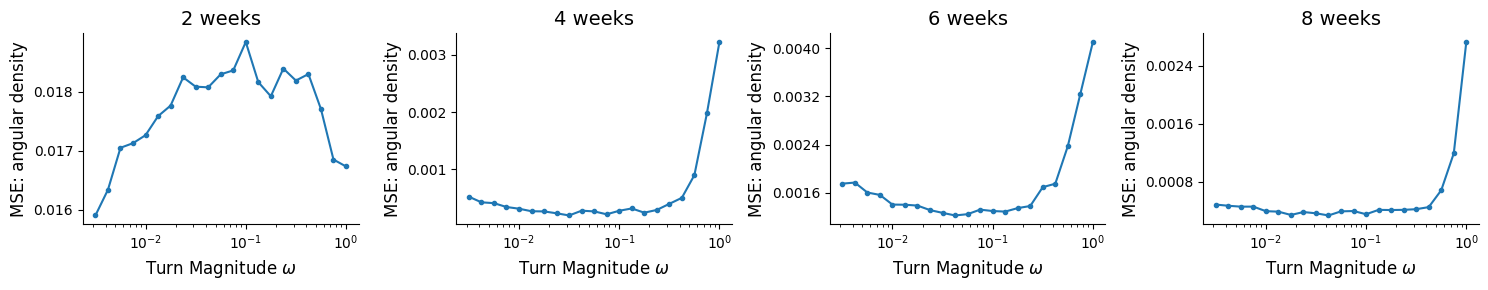

In [17]:
# plot MSE vs turn magnitude omega for each age
fig, ax = plt.subplots(1,4,figsize=(15, 3))
for j in range(len(fish_ages)):
    ax[j].plot(omega_list, MSE_angular_density[:,j], label=f"{fish_ages[j]} weeks", marker='.')
    ax[j].set_xlabel(r'Turn Magnitude $\omega$', fontsize=12)
    ax[j].set_ylabel('MSE: angular density', fontsize=12)
    ax[j].set_xscale('log')
    ax[j].set_title(f"{fish_ages[j]} weeks", fontsize=14)
    # turn off top and right spines
    ax[j].spines['top'].set_visible(False)
    ax[j].spines['right'].set_visible(False)
    ax[j].tick_params(axis='both', which='major', labelsize=10)
    ax[j].set_xticks([0.01,0.1,1])
    ax[j].yaxis.set_major_locator(MaxNLocator(nbins=4))
fig.tight_layout()

### Find optimal $\omega$ by averaging MSE for 4-8 weeks
2wpf fish do not show marked angular anisotropy, so we will only use data from 4-8 wpf fish 

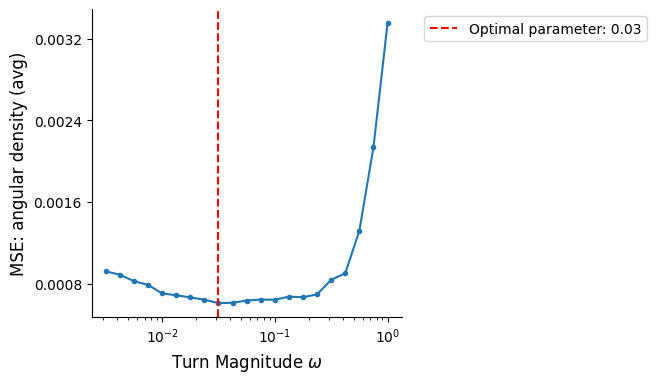

In [18]:
# avg 4-8 weeks and find optimal
MSE_angular_avg = np.mean(MSE_angular_density[:,1:], axis=1)
omega_optimal = omega_list[np.argmin(MSE_angular_avg)]

fig, ax = plt.subplots(1,1,figsize=(4, 4))
ax.plot(omega_list, MSE_angular_avg, marker='.')
ax.axvline(omega_optimal, color='r', linestyle='--', label=f'Optimal parameter: {omega_optimal:.2f}')
ax.set_xlabel(r'Turn Magnitude $\omega$', fontsize=12)
ax.set_ylabel('MSE: angular density (avg)', fontsize = 12)
ax.set_xscale('log')
# turn off top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', which='major', labelsize=10)
ax.set_xticks([0.01,0.1,1])
ax.yaxis.set_major_locator(MaxNLocator(nbins=4))
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')



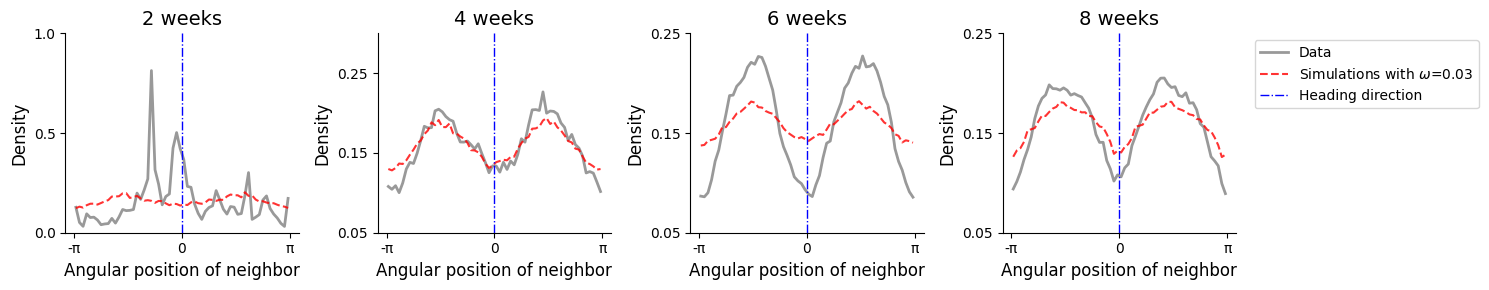

In [19]:
# angular density simulation results for optimal turn magnitude
fig, ax = plt.subplots(1, 4, figsize=(15, 3))
lims = [[0,1], [0.05,0.3], [0.05,0.25], [0.05,0.25]]
ticks = [[0,0.5,1], [0.05,0.15,0.25], [0.05,0.15,0.25], [0.05,0.15,0.25]]
for j in range(len(fish_ages)):
    angles = np.copy(angular_density_curves_data[j][:,0])
    angles[angles<-np.pi/2] += 2*np.pi
    angles = angles - np.pi/2 # shift so that 0 is heading direction

    # sort angles and corresponding densities
    sorted_indices = np.argsort(angles)
    angles = angles[sorted_indices]
    ax[j].plot(angles, angular_density_curves_data[j][sorted_indices,1], color='grey', label='Data', linewidth=2, alpha=0.8)
    ax[j].plot(angles, angular_histograms[np.argmin(MSE_angular_avg),j,sorted_indices,1], color='r', linestyle='--', label=fr'Simulations with $\omega$={omega_optimal:.2f}', linewidth=1.5, alpha=0.8)
    ax[j].set_title(f"{fish_ages[j]} weeks", fontsize=14)
    ax[j].set_xlabel('Angular position of neighbor', fontsize=12)
    ax[j].set_ylabel('Density', fontsize=12)
    ax[j].set_xticks([-np.pi, 0, np.pi],['-π', '0',  'π'])
    ax[j].tick_params(axis='both', which='major', labelsize=10)
    ax[j].set_ylim(lims[j])
    ax[j].set_yticks(ticks[j])
    #ax[j].yaxis.set_major_locator(MaxNLocator(nbins=4))
    # turn off top and right spines
    ax[j].spines['top'].set_visible(False)
    ax[j].spines['right'].set_visible(False)
    ax[j].axvline(0, color='b', linestyle='-.', linewidth=1, label='Heading direction')
ax[-1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
fig.tight_layout()

In [20]:
omega_optimal

np.float64(0.03162277660168379)

# Full density plots
Using same number of simulations as experiments!

In [23]:
def run_sims_and_analyse_density(agewise_params=microscopic_params, 
                                 arena_radii=[75, 150, 150, 150],  
                                 N_fish=4, 
                                 Tmax = 300, 
                                 L=L, 
                                 dt=0.01, 
                                 N_sims= 10, 
                                 fish_ages = fish_ages,
                                 excluded_volume=False,
                                 omega_optimal=omega_optimal,
                                 ):

    frames = int(Tmax/dt) + 1
    N_ages = len(fish_ages)

    # arrays to save results
    dFB_all_ages = [[] for _ in range(N_ages)]
    dLR_all_ages = [[] for _ in range(N_ages)]

    for j, age in enumerate(fish_ages):
        s = np.ones(N_fish)*agewise_params[j,0] # s^-1, rate of diffusion
        eps = np.ones(N_fish)*agewise_params[j,1] # variance of diffusion noise
        c = np.ones(N_fish)*agewise_params[j,2] # s^-1, rate of copying
        v = np.ones(N_fish)*agewise_params[j,3] #mm/s, velocity of each fish
        R = arena_radii[j] #mm, radius of arena
        dFB_all_sims = []
        dLR_all_sims = []

        for kk in range(N_sims):
            if excluded_volume:
                sim = Simulate_Fish_School_Excluded_Volume(
                    N= N_fish,
                    v = v,
                    R=R,
                    s=s,
                    eps=eps,
                    c=c,
                    Tmax=Tmax,
                    dt=dt, 
                    L=L,
                    omega=omega_optimal,
                    R_ex = bodylengths[j],
                    seed=kk
                )
            else:
                sim = Simulate_Fish_School(
                    N = N_fish,
                    v = v,
                    R=R,
                    s=s,
                    eps=eps,
                    c=c,
                    Tmax=Tmax,
                    dt=dt, 
                    L=L,
                    seed=kk
                )

            x,y,theta = sim.run_simulation()
            # find dFB and dLR for all fish
            for f in range(N_fish):
                dFB, dLR = convert_to_focal_distance(f,x,y,theta)
                nan_mask = np.isfinite(dLR+dFB)
                dFB_all_sims.append(dFB[nan_mask])
                dLR_all_sims.append(dLR[nan_mask])

        dFB_all_sims = np.concatenate(dFB_all_sims)
        dLR_all_sims = np.concatenate(dLR_all_sims)
        dFB_all_ages[j] = dFB_all_sims
        dLR_all_ages[j] = dLR_all_sims

        print(f"{age}wpf completed at {datetime.now().strftime('%H:%M:%S')}")

    # save analysis results
    analysis_results_sims = {
        'dFB': dFB_all_ages,
        'dLR': dLR_all_ages
        }
     
    return analysis_results_sims

### Without excluded volume

In [24]:
results_path = Path('../../Results/model_spatial_density_no_exclusion.pkl')
if results_path.is_file():
    with open(results_path, 'rb') as f:
        model_spatial_density_no_exclusion = pickle.load(f)
else:
    model_spatial_density_no_exclusion = run_sims_and_analyse_density(N_sims = 100,
                                                                      Tmax = 600,
                                                                      excluded_volume=False)

    # save results
    with open(results_path, 'wb') as f:
        pickle.dump(model_spatial_density_no_exclusion, f)


2wpf completed at 14:16:24
4wpf completed at 14:18:29
6wpf completed at 14:20:36
8wpf completed at 14:22:46


### With excluded volume

In [25]:
results_path = Path('../../Results/model_spatial_density_with_exclusion.pkl')
if results_path.is_file():
    with open(results_path, 'rb') as f:
        model_spatial_density_with_exclusion = pickle.load(f)
else:
    model_spatial_density_with_exclusion = run_sims_and_analyse_density(N_sims = 100,
                                                                      Tmax = 600,
                                                                      excluded_volume=True)

    # save results
    with open(results_path, 'wb') as f:
        pickle.dump(model_spatial_density_with_exclusion, f)

2wpf completed at 14:25:41
4wpf completed at 14:28:36
6wpf completed at 14:31:33
8wpf completed at 14:34:30


In [26]:
# calculate angular density for both simulations

angular_density_no_exclusion = np.zeros((len(fish_ages), nbins_theta))
angular_density_with_exclusion = np.zeros((len(fish_ages), nbins_theta))

for j in range(len(fish_ages)):
    # without exclusion
    dFB = model_spatial_density_no_exclusion['dFB'][j]
    dLR = model_spatial_density_no_exclusion['dLR'][j]
    r = np.sqrt(dFB**2 + dLR**2)
    theta = np.arctan2(dFB, dLR)
    theta_red = theta[r<2*bodylengths[j]] # only consider points within 2 body lengths
    angular_hist, _ = np.histogram(theta_red, bins=bins_theta_edges, density=True)
    angular_density_no_exclusion[j,:] = angular_hist

    # with exclusion
    dFB = model_spatial_density_with_exclusion['dFB'][j]
    dLR = model_spatial_density_with_exclusion['dLR'][j]
    r = np.sqrt(dFB**2 + dLR**2)
    theta = np.arctan2(dFB, dLR)
    theta_red = theta[r<2*bodylengths[j]] # only consider points within 2 body lengths
    angular_hist, _ = np.histogram(theta_red, bins=bins_theta_edges, density=True)
    angular_density_with_exclusion[j,:] = angular_hist



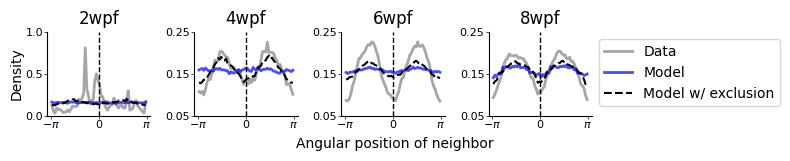

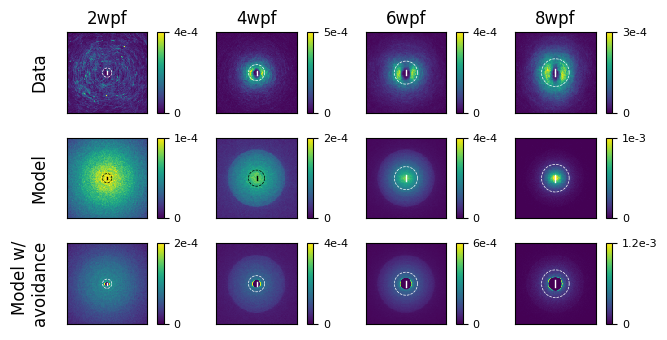

In [30]:
# plot 
labelsize = 10
ticksize = 8
titlesize = 12

fig, ax = plt.subplots(1,4,figsize=(8,1.5))

fig_d, ax_d = plt.subplots(3,4,figsize=(6.8,3.5))
bins = np.linspace(-70,70,100)

density_lims = [
    [0,1],
    [0.05,0.25],
    [0.05,0.25],
    [0.05,0.25]
]

density_ticks = [
    [0,0.5,1],
    [0.05,0.15,0.25],
    [0.05,0.15,0.25],
    [0.05,0.15,0.25]
]

cbar_ticks_data = [
    10**-4*np.array([0,4]),
    10**-4*np.array([0,5]),
    10**-4*np.array([0,4]),
    10**-4*np.array([0, 3])
]

cbar_ticks_wo_exclusion = [
    10**-4*np.array([0,1]),
    10**-4*np.array([0,2]),
    10**-4*np.array([0,4]),
    10**-3*np.array([0, 1])
]

cbar_ticks_with_exclusion = [
    10**-4*np.array([0,2]),
    10**-4*np.array([0,4]),
    10**-4*np.array([0,6]),
    10**-3*np.array([0, 1.2])
]

cbar_ticklabels_data = [
    ["0","4e-4"],
    ["0","5e-4"],
    ["0","4e-4"],
    ["0","3e-4"]
]

cbar_ticklabels_wo_exclusion = [
    ["0","1e-4"],
    ["0","2e-4"],
    ["0","4e-4"],
    ["0","1e-3"]
]
cbar_ticklabels_with_exclusion = [
    ["0","2e-4"],
    ["0","4e-4"],
    ["0","6e-4"],
    ["0","1.2e-3"]
]


# rotating and shifting angles for angular density plots
angles = np.copy(angular_density_curves_data[0][:,0])
angles[angles<-np.pi/2] += 2*np.pi
angles = angles - np.pi/2 # shift so that 0 is heading direction
# sort angles and corresponding densities
sorted_indices = np.argsort(angles)
angles = angles[sorted_indices]

for j, age in enumerate(fish_ages):
    # angular densities
    ax[j].plot(angles, angular_density_curves_data[j][sorted_indices,1], color='grey', label='Data', linewidth=2, alpha=0.7)
    ax[j].plot(angles, angular_density_no_exclusion[j,sorted_indices], color='b', linestyle='-', label=f'Model', linewidth=2, alpha=0.7)
    ax[j].plot(angles, angular_density_with_exclusion[j,sorted_indices], color='k', linestyle='--', label=f'Model w/ exclusion', linewidth=1.5, alpha=1)
    #ax[0,j].set_xlabel('Angular position\nof neighbor', fontsize=12)
    ax[j].set_xticks([-np.pi, 0, np.pi],[r'$-\pi$','0',r'$\pi$'])
    ax[j].tick_params(axis='both', which='major', labelsize=ticksize, pad=1, width=0.5, length=2)
    ax[j].set_ylim(density_lims[j])
    ax[j].set_yticks(density_ticks[j])
    if j==0:
        ax[j].set_ylabel('Density', fontsize=labelsize, labelpad=1)
    ax[j].set_title(f"{age}wpf", fontsize=titlesize)
    # turn off top and right spines
    ax[j].spines['top'].set_visible(False)
    ax[j].spines['right'].set_visible(False)
    ax[j].axvline(0, color='k', linestyle='--', linewidth=1)
    # # legend outside last plot
    # if j==3:
    #     ax[j].legend(loc='upper left', bbox_to_anchor=(1.05, 1), fontsize=ticksize, frameon=False)
    
    # 2D density data
    dLR = data_focal_distances_agewise[j][:,0]
    dFB = data_focal_distances_agewise[j][:,1]
    im=ax_d[0,j].hist2d(dLR,dFB, cmap='viridis',bins=bins,density=True, vmin=0, rasterized=True, vmax=cbar_ticks_data[j][-1])
    #get colorbar of the right height
    divider = make_axes_locatable(ax_d[0,j])
    cax = divider.append_axes("right", size="8%", pad=0.1)  # Adjust the size and pad as needed
    cbar = plt.colorbar(im[3], cax=cax)
    cbar.ax.tick_params(labelsize=ticksize)
    #cbar.set_label('Density',fontsize=labelsize, labelpad=0.1)
    cbar.set_ticks(cbar_ticks_data[j], labels=cbar_ticklabels_data[j])
    bl = bodylengths[j]
    ax_d[0,j].plot([0,0],[-bl/2,bl/2],color='w', linewidth=1)
    ax_d[0,j].set_title(f"{age}wpf",fontsize=titlesize)
    ax_d[0,j].set_xlim([bins[0],bins[-1]])
    ax_d[0,j].set_ylim([bins[0],bins[-1]])
    ax_d[0,j].set_yticks([])
    ax_d[0,j].set_xticks([])
    ax_d[0,j].set_aspect('equal')
    temp = np.linspace(0,2*np.pi,100)
    ax_d[0,j].plot(2*bl*np.cos(temp), 2*bl*np.sin(temp), 'w--', linewidth=0.5)

    # 2D density simulations without exclusion
    dFB = model_spatial_density_no_exclusion['dFB'][j]
    dLR = model_spatial_density_no_exclusion['dLR'][j]
    im=ax_d[1,j].hist2d(dLR,dFB, cmap='viridis',bins=bins,density=True, vmin=0, rasterized=True, vmax=cbar_ticks_wo_exclusion[j][-1])
    #get colorbar of the right height
    divider = make_axes_locatable(ax_d[1,j])
    cax = divider.append_axes("right", size="8%", pad=0.1)  # Adjust the size and pad as needed
    cbar = plt.colorbar(im[3], cax=cax)
    cbar.ax.tick_params(labelsize=ticksize)
    #cbar.set_label('Density',fontsize=labelsize, labelpad=0.1)
    cbar.set_ticks(cbar_ticks_wo_exclusion[j], labels=cbar_ticklabels_wo_exclusion[j])
    #ax[2,j].set_title("Sims without\ncollision avoidance",fontsize=14)
    ax_d[1,j].set_xlim([bins[0],bins[-1]])
    ax_d[1,j].set_ylim([bins[0],bins[-1]])
    ax_d[1,j].set_yticks([])
    ax_d[1,j].set_xticks([])
    ax_d[1,j].set_aspect('equal')
    temp = np.linspace(0,2*np.pi,100)
    color ="k" if j<2 else "w"
    bl = bodylengths[j]
    ax_d[1,j].plot([0,0],[-bl/2,bl/2],color=color, linewidth=1)
    temp = np.linspace(0,2*np.pi,100)
    ax_d[1,j].plot(2*bl*np.cos(temp), 2*bl*np.sin(temp), color=color, linestyle='--', linewidth=0.5)

    # 2D density simulations with exclusion
    dFB = model_spatial_density_with_exclusion['dFB'][j]
    dLR = model_spatial_density_with_exclusion['dLR'][j]
    im=ax_d[2,j].hist2d(dLR,dFB, cmap='viridis',bins=bins,density=True, vmin=0, rasterized=True, vmax=cbar_ticks_with_exclusion[j][-1])
    #get colorbar of the right height
    divider = make_axes_locatable(ax_d[2,j])
    cax = divider.append_axes("right", size="8%", pad=0.1)  # Adjust the size and pad as needed
    cbar = plt.colorbar(im[3], cax=cax)
    cbar.ax.tick_params(labelsize=ticksize)
    #cbar.set_label('Density',fontsize=labelsize, labelpad=0.1)
    cbar.set_ticks(cbar_ticks_with_exclusion[j], labels=cbar_ticklabels_with_exclusion[j])
    #ax[3,j].set_title("Sims with\ncollision avoidance",fontsize=14)
    ax_d[2,j].set_xlim([bins[0],bins[-1]])
    ax_d[2,j].set_ylim([bins[0],bins[-1]])
    ax_d[2,j].set_yticks([])
    ax_d[2,j].set_xticks([])
    ax_d[2,j].set_aspect('equal')
    color ="w"
    bl = bodylengths[j]
    ax_d[2,j].plot([0,0],[-bl/2,bl/2],color='w', linewidth=1)
    temp = np.linspace(0,2*np.pi,100)
    ax_d[2,j].plot(2*bl*np.cos(temp), 2*bl*np.sin(temp), 'w--', linewidth=0.5)

#legend
ax[-1].legend(loc="upper left", bbox_to_anchor=(1,1))

# add annotation to the rows of fig_d
row_titles = ['Data', 'Model', 'Model w/\navoidance']
for ax, row_title in zip(ax_d[:,0], row_titles):
    y = 0
    ax.annotate(row_title, xy=(0, 0.5), xytext=(-ax.yaxis.labelpad - 5, y),
                xycoords=ax.yaxis.label, textcoords='offset points',
                size=titlesize, ha='right', va='center', rotation=90)
fig_d.tight_layout()

# common x label for angular density
fig.text(0.5, -0.02, 'Angular position of neighbor', ha='center', fontsize=labelsize)
fig.tight_layout()

    